In [1]:
import pandas as pd

In [4]:
data = pd.read_csv(r"C:\Users\admin\OneDrive\Desktop\FT\Final Mock Test\AQI_Dataset.csv")

In [5]:
data["Date"] = pd.to_datetime(data["Date"])

In [6]:
data["Year"] = data["Date"].dt.year
data["Day"] = data["Date"].dt.day

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
enc = LabelEncoder()

In [9]:
data["City_En"] = enc.fit_transform(data["City"])

In [10]:
y = data["AQI"]

In [11]:
x = data.drop(["AQI", "AQI_Bucket", "City", "Date", "Record_ID", "Id_AQI"],axis=1)

In [12]:
x.shape

(29531, 14)

In [13]:
y.shape

(29531,)

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.7,random_state=34)

In [16]:
from sklearn.preprocessing import StandardScaler

In [19]:
scale = StandardScaler()

In [23]:
x_train_scale = scale.fit_transform(x_train)
x_test_scale = scale.transform(x_test)

In [24]:
x_train_scale = pd.DataFrame(x_train_scale, columns=x_train.columns, index=x_train.index)

In [25]:
x_test_scale = pd.DataFrame(x_test_scale, columns=x_test.columns, index=x_test.index)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
lr = LinearRegression()

In [28]:
lr.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
pre = lr.predict(x_test_scaled)

In [31]:
prediction = pd.DataFrame({"Actual AQI": y_test.values[:10], "Predicted AQI": pre[:10]})

In [36]:
prediction

,Actual AQI,Predicted AQI
0,86.0,96.335166
1,63.0,82.764141
2,238.0,181.256158
3,150.0,162.990907
4,185.0,180.923552
5,49.0,59.295559
6,134.0,161.083373
7,54.0,59.831566
8,130.0,102.589399
9,147.0,164.476566


In [34]:
print("Intercept:", lr.intercept_)

Intercept: 163.4466644090755


In [35]:
coef_data = pd.DataFrame({"Feature": x.columns,"Coefficient": lr.coef_})

coef_data

,Feature,Coefficient
0,PM2.5,5.764658e+01
1,PM10,2.182670e+01
2,NO,-2.532181e+00
3,NO2,9.465890e+00
4,NOx,4.320812e+00
5,CO,7.069332e+01
6,O3,4.372030e+00
7,Benzene,-5.138667e+00
8,Toluene,6.759932e+00
9,Xylene,-3.552714e-15


In [38]:
enc2 = LabelEncoder()

data["AQI_Bucket_En"] = enc2.fit_transform(data["AQI_Bucket"])

In [40]:
X_rf = data.drop(["AQI", "AQI_Bucket","AQI_Bucket_En","City","Date","Record_ID","Id_AQI"],axis=1)

y_rf = data["AQI_Bucket_En"]

In [42]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf,y_rf,test_size=0.3,random_state=34)

In [43]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf,y_rf,test_size=0.3,random_state=34,stratify=y_rf)

In [44]:
scale_rf = StandardScaler()

In [45]:
X_train_rf_scaled = scale_rf.fit_transform(X_train_rf)
X_test_rf_scaled = scale_rf.transform(X_test_rf)

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
rf = RandomForestClassifier(n_estimators=100,random_state=34)

In [48]:
rf.fit(X_train_rf_scaled, y_train_rf)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
pre = rf.predict(X_test_rf_scaled)

In [52]:
rf_prediction_data = pd.DataFrame({"Actual AQI_Bucket": enc2.inverse_transform(y_test_rf.values[:10]),"Predicted AQI_Bucket": enc2.inverse_transform(
pre[:10])})

In [53]:
rf_prediction_data

,Actual AQI_Bucket,Predicted AQI_Bucket
0,Moderate,Moderate
1,Moderate,Moderate
2,Moderate,Satisfactory
3,Moderate,Satisfactory
4,Satisfactory,Satisfactory
5,Satisfactory,Satisfactory
6,Moderate,Moderate
7,Moderate,Moderate
8,Moderate,Moderate
9,Good,Good


In [54]:
from sklearn.metrics import r2_score

In [56]:
r2 = r2_score(y_test, pre)

In [57]:
print("Linear Regression R2 Score:", r2)

Linear Regression R2 Score: -1.553243471481252


In [66]:
from sklearn.metrics import root_mean_squared_error

In [67]:
rmse = root_mean_squared_error(y_test,pre) 

In [68]:
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 208.6354129888965


In [80]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [74]:
accuracy = accuracy_score(y_test_rf,pre)

In [75]:
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.8178329571106094


In [76]:
cm = confusion_matrix(y_test_rf,pre)

In [77]:
import seaborn as sns

<Axes: >

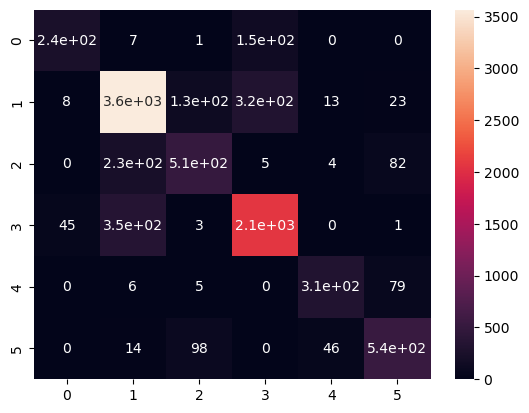

In [79]:
sns.heatmap(cm,annot=True)

In [81]:
print(classification_report(y_test_rf, pre))

              precision    recall  f1-score   support

           0       0.82      0.60      0.69       402
           1       0.85      0.88      0.87      4053
           2       0.69      0.62      0.65       834
           3       0.81      0.84      0.83      2468
           4       0.83      0.78      0.80       402
           5       0.75      0.77      0.76       701

    accuracy                           0.82      8860
   macro avg       0.79      0.75      0.77      8860
weighted avg       0.82      0.82      0.82      8860

